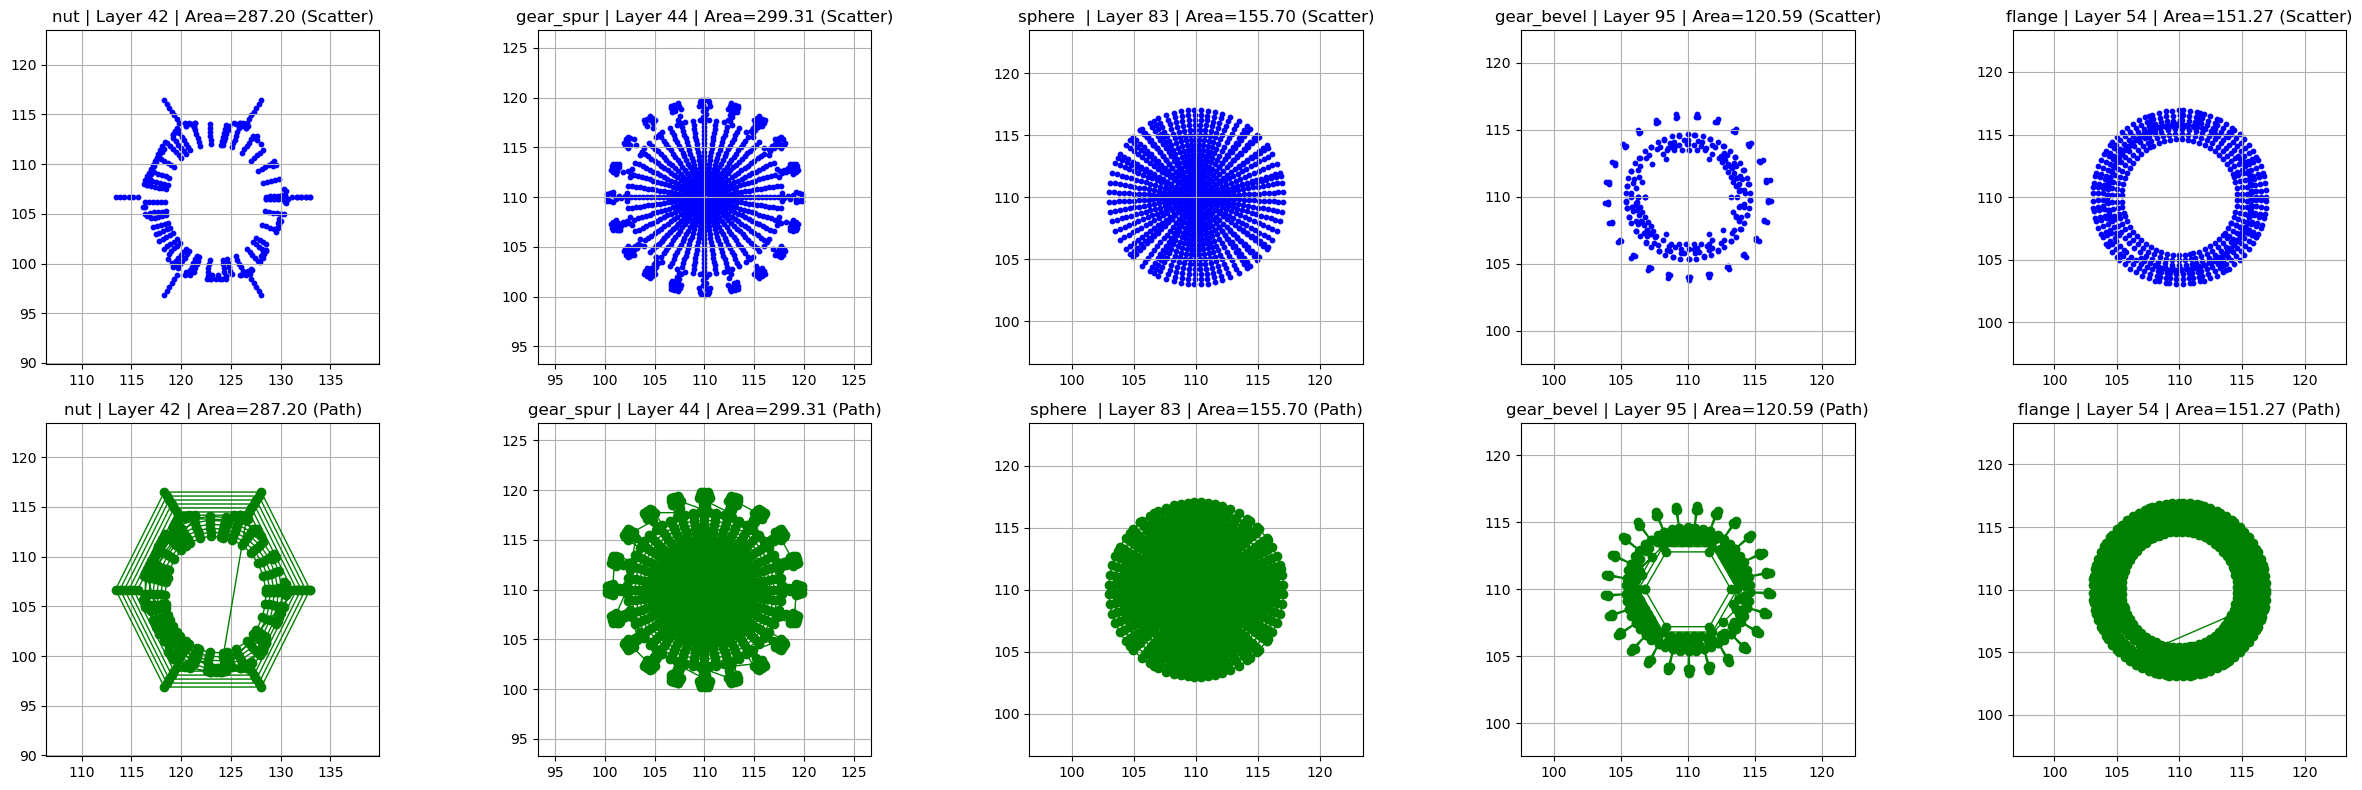

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

# === Load the new .npy file ===
npy_path = r"F:\JupyterWork\Testing GAN\Coding of GAN\Datasetv3\gcode_layers_V4.npy"
loaded = np.load(npy_path, allow_pickle=True).item()

X = loaded["data"]             # [num_files, max_layers, max_points, 2]
y = loaded["labels"]           # integer labels
label_map = loaded["label_map"]  # dict {name: int}
layer_indices = loaded["layer_indices"]  # [num_files, max_layers]
areas = loaded["areas"]        # [num_files, max_layers] (raw areas)
name_map = {v: k for k, v in label_map.items()}  # reverse lookup

# === Flatten all layers with their label & layer index ===
samples = []
for i, file in enumerate(X):
    for j, layer in enumerate(file):
        if np.any(layer):   # skip all-zero padding
            samples.append((layer, y[i], layer_indices[i, j], areas[i, j]))  
            # (points, label, layer_num, raw_area)

# === Randomly pick 5 layers ===
selected_layers = random.sample(samples, 5)

# === Plotting horizontally: 2 rows (scatter & line), 5 columns ===
fig, axs = plt.subplots(2, 5, figsize=(25, 8))

for col, (layer, label, layer_num, raw_area) in enumerate(selected_layers):
    # Remove zero-padded rows
    points = layer[~np.all(layer == 0, axis=1)]

    # Auto margins
    x_min, x_max = points[:, 0].min(), points[:, 0].max()
    y_min, y_max = points[:, 1].min(), points[:, 1].max()
    x_margin = (x_max - x_min) * 0.1 + 5
    y_margin = (y_max - y_min) * 0.1 + 5

    # === Top Row: Scatter ===
    axs[0, col].scatter(points[:, 0], points[:, 1], s=10, color='blue')
    axs[0, col].set_title(f"{name_map[label]} | Layer {layer_num} | Area={raw_area:.2f} (Scatter)")
    axs[0, col].set_aspect('equal')
    axs[0, col].grid(True)
    axs[0, col].set_xlim(x_min - x_margin, x_max + x_margin)
    axs[0, col].set_ylim(y_min - y_margin, y_max + y_margin)

    # === Bottom Row: Path (line plot) ===
    axs[1, col].plot(points[:, 0], points[:, 1], marker='o', linewidth=1, color='green')
    axs[1, col].set_title(f"{name_map[label]} | Layer {layer_num} | Area={raw_area:.2f} (Path)")
    axs[1, col].set_aspect('equal')
    axs[1, col].grid(True)
    axs[1, col].set_xlim(x_min - x_margin, x_max + x_margin)
    axs[1, col].set_ylim(y_min - y_margin, y_max + y_margin)

plt.tight_layout()
plt.show()


In [1]:
#Environment Test
#%%
import torch
import pytorch3d
from pytorch3d.ops import knn_points


#%%
print(pytorch3d.__version__)
print(f"torch version: {torch.__version__}")
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
!python --version

#%%
p1 = torch.rand((1, 100, 3), device='cuda')
p2 = torch.rand((1, 200, 3), device='cuda')
knn = knn_points(p1, p2, K=1)
print("KNN distances shape:", knn.dists.shape)


#%%


0.7.8
torch version: 2.2.0+cu121
CUDA available: True
CUDA version: 12.1
Python 3.11.5
KNN distances shape: torch.Size([1, 100, 1])


In [1]:
# =====================================================
# Conditional AutoEncoder (cAE) for G-code Layers (5-Fold CV)
# Conditions: areas_norm (continuous) + label one-hot (categorical)
# =====================================================
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# === Imports ===
import random
from sklearn.model_selection import KFold
import yaml
import torch
import numpy as np
import matplotlib.pyplot as plt
from box import Box
from tqdm import tqdm
from pathlib import Path
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from pytorch3d.loss import chamfer_distance
import torch.nn.functional as F

# === Config ===
with open("config.yaml", "r") as file:
    args = Box(yaml.safe_load(file))

args.data_dir = Path.home() / args.data_dir
args.model_dir = Path.home() / args.model_dir
args.output_folder = Path(args.output_folder)
args.output_folder.mkdir(parents=True, exist_ok=True)

# === Load Dataset (Dictionary) ===
data_file = args.data_dir / args.dataset
dataset_dict = np.load(data_file, allow_pickle=True).item()

raw_pc_array   = dataset_dict["data"]            # (num_files, max_layers, max_points, 2)
layer_indices  = dataset_dict["layer_indices"]   # (num_files, max_layers)
labels_file    = dataset_dict["labels"]          # (num_files,) int label per file
label_map      = dataset_dict["label_map"]       # dict name->int
areas_norm_all = dataset_dict["areas_norm"]      # (num_files, max_layers) in [0,1]

num_classes = len(label_map)

print("✅ Loaded dataset")
print(f"Data shape: {raw_pc_array.shape}")
print(f"Label map: {label_map} (num_classes={num_classes})")
print(f"Layer indices shape: {layer_indices.shape}")
print(f"areas_norm shape: {areas_norm_all.shape}")

# === Flatten valid layers across files (keep area + label) ===
flat = []  # list of tuples: (points[N,2], area_norm_scalar, label_int)
for f in range(raw_pc_array.shape[0]):          # loop files
    for l in range(raw_pc_array.shape[1]):      # loop layers
        pc = raw_pc_array[f, l]
        # remove zero-padded rows
        pts = pc[~np.all(pc == 0, axis=1)]
        if pts.shape[0] > 0:
            area_l = float(areas_norm_all[f, l])
            label_f = int(labels_file[f])
            flat.append((pts, area_l, label_f))

print(f"✅ Flattened total valid layers: {len(flat)}")

# === Compute max number of points among valid layers ===
max_points = max(pts.shape[0] for (pts, _, _) in flat)
print(f"✅ Max points in any layer: {max_points}")

# === Normalize & pad each layer; collect area + label alongside ===
def normalize_and_repeat_2d(pc, target_size):
    # Normalize: center + scale to unit radius
    centroid = np.mean(pc, axis=0)
    pc = pc - centroid
    max_dist = np.max(np.linalg.norm(pc, axis=1))
    if max_dist < 1e-8 or np.isnan(max_dist):
        return None
    pc = pc / max_dist
    # Pad by repeating to target_size (no zero padding -> keeps Chamfer stable)
    if pc.shape[0] < target_size:
        rep = (target_size // pc.shape[0]) + 1
        pc = np.tile(pc, (rep, 1))[:target_size]
    elif pc.shape[0] > target_size:
        pc = pc[:target_size]
    return pc

pts_list, area_list, label_list = [], [], []
for (pts, area_norm_scalar, label_int) in flat:
    pcn = normalize_and_repeat_2d(pts, max_points)
    if pcn is None: 
        continue
    pts_list.append(pcn)
    area_list.append(area_norm_scalar)
    label_list.append(label_int)

pc_array   = np.array(pts_list, dtype=np.float32)                   # (N, P, 2)
area_array = np.array(area_list, dtype=np.float32).reshape(-1, 1)   # (N, 1)
label_int  = np.array(label_list, dtype=np.int64)                   # (N,)

print("✅ Data after normalization:")
print(f"points: {pc_array.shape}, areas_norm: {area_array.shape}, labels: {label_int.shape}")

# === Dataset Class (returns points, area_norm, label_onehot) ===
class PointDataset(Dataset):
    def __init__(self, points_np, areas_np, label_int_np, num_classes):
        self.points = torch.tensor(points_np, dtype=torch.float32)              # (N,P,2)
        self.areas  = torch.tensor(areas_np, dtype=torch.float32)               # (N,1)
        self.labels = torch.tensor(label_int_np, dtype=torch.long)              # (N,)
        self.num_classes = num_classes

    def __len__(self):
        return self.points.shape[0]

    def __getitem__(self, idx):
        x   = self.points[idx]                         # (P,2)
        a   = self.areas[idx]                          # (1,)
        y   = self.labels[idx]                         # ()
        y1h = F.one_hot(y, num_classes=self.num_classes).float()  # (C,)
        return x, a, y1h

dataset = PointDataset(pc_array, area_array, label_int, num_classes)

# === Model: cAE (decoder conditioned on area + label) ===
class PointCloudCAE(torch.nn.Module):
    def __init__(self, point_size, latent_size, cond_dim):
        """
        point_size: P (number of points)
        latent_size: dim of latent z
        cond_dim: 1 (area) + num_classes (label one-hot)
        """
        super().__init__()
        self.P = point_size
        self.enc = torch.nn.Sequential(
            torch.nn.Linear(point_size * 2, 1024),
            torch.nn.ReLU(),
            torch.nn.Linear(1024, 512),
            torch.nn.ReLU(),
            torch.nn.Linear(512, 256),
            torch.nn.ReLU(),
            torch.nn.Linear(256, latent_size),
        )
        self.dec = torch.nn.Sequential(
            torch.nn.Linear(latent_size + cond_dim, 256),
            torch.nn.ReLU(),
            torch.nn.Linear(256, 512),
            torch.nn.ReLU(),
            torch.nn.Linear(512, 1024),
            torch.nn.ReLU(),
            torch.nn.Linear(1024, point_size * 2),
        )

    def forward(self, x, cond):
        """
        x: (B,P,2)
        cond: (B, cond_dim)  = [area_norm (B,1) || label_onehot (B,C)]
        """
        B = x.shape[0]
        x_flat = x.view(B, -1)
        z = self.enc(x_flat)              # (B, latent)
        zc = torch.cat([z, cond], dim=1)  # (B, latent + cond)
        out_flat = self.dec(zc)           # (B, P*2)
        out = out_flat.view(B, self.P, 2)
        return out

# === Setup ===
device = 'cuda'  # if torch.cuda.is_available() else 'cpu'
point_size = pc_array.shape[1]
cond_dim = 1 + num_classes

# === Train/Test ===
def train_epoch(train_loader, cae, optimizer):
    cae.train()
    total = 0.0
    for i, batch in enumerate(train_loader):
        x, a, y1h = batch
        x = x.to(device)
        a = a.to(device)          # (B,1)
        y1h = y1h.to(device)      # (B,C)
        cond = torch.cat([a, y1h], dim=1)  # (B, 1+C)

        optimizer.zero_grad()
        x_hat = cae(x, cond)
        loss, _ = chamfer_distance(x, x_hat)
        loss.backward()
        optimizer.step()
        total += loss.item()
    return total / (i + 1)

def test_epoch(test_loader, cae):
    cae.eval()
    total = 0.0
    with torch.no_grad():
        for i, batch in enumerate(test_loader):
            x, a, y1h = batch
            x = x.to(device)
            a = a.to(device)
            y1h = y1h.to(device)
            cond = torch.cat([a, y1h], dim=1)
            x_hat = cae(x, cond)
            loss, _ = chamfer_distance(x, x_hat)
            total += loss.item()
    return total / (i + 1)

# === Plotting reconstructions ===
def plotPCbatch_2d(batch_input, batch_output, show=True, save=False, name="plot"):
    batch_input = batch_input.cpu().numpy()
    batch_output = batch_output.cpu().numpy()
    cols = min(5, batch_input.shape[0])
    fig, axs = plt.subplots(2, cols, figsize=(3.0*cols, 5))
    if cols == 1:
        axs = np.array([[axs[0]], [axs[1]]])
    for i in range(cols):
        axs[0, i].scatter(batch_input[i, :, 0], batch_input[i, :, 1], c='b', s=2)
        axs[1, i].scatter(batch_output[i, :, 0], batch_output[i, :, 1], c='r', s=2)
        axs[0, i].axis('equal'); axs[1, i].axis('equal')
        axs[0, i].grid(True); axs[1, i].grid(True)
        axs[0, i].set_title("Input"); axs[1, i].set_title("Recon")
    plt.tight_layout()
    if save:
        plt.savefig(f"{name}.png")
        plt.close()
    elif show:
        plt.show()

# === 5-Fold Cross Validation ===
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, test_idx) in enumerate(kf.split(range(len(dataset))), 1):
    print(f"\n==== Fold {fold} ====")

    # Subsets & loaders
    train_ds = torch.utils.data.Subset(dataset, train_idx)
    test_ds  = torch.utils.data.Subset(dataset, test_idx)

    train_loader = DataLoader(train_ds, batch_size=args.batch_size, shuffle=True,  num_workers=0)
    test_loader  = DataLoader(test_ds,  batch_size=args.batch_size, shuffle=False, num_workers=0)

    # Model + optimizer
    cae = PointCloudCAE(point_size, args.latent_size, cond_dim).to(device)
    optimizer = optim.AdamW(cae.parameters(), lr=1e-3, weight_decay=1e-5)

    train_losses, test_losses = [], []

    for epoch in range(args.ae_epoch):
        train_loss = train_epoch(train_loader, cae, optimizer)
        test_loss  = test_epoch(test_loader, cae)

        train_losses.append(train_loss)
        test_losses.append(test_loss)
        print(f"Fold {fold} | Epoch {epoch}: Train={train_loss:.4f}, Test={test_loss:.4f}")

        # Save loss curve every epoch (overwrites, so always up-to-date)
        plt.figure(figsize=(8,5))
        plt.plot(train_losses, label="Train Loss")
        plt.plot(test_losses, label="Test Loss")
        plt.xlabel("Epoch"); plt.ylabel("Chamfer Loss")
        plt.title(f"Fold {fold} Loss Curve (up to epoch {epoch})")
        plt.legend(); plt.grid(True)
        plt.savefig(args.output_folder / f"fold{fold}_loss.png")
        plt.close()

        # Save reconstructions + model every 50 epochs
        if epoch % 50 == 0:
            n_samples = min(5, len(test_ds))
            rand_indices = random.sample(range(len(test_ds)), n_samples)
            batch_in = []
            cond_in  = []
            for idx in rand_indices:
                x, a, y1h = test_ds[idx]
                batch_in.append(x)
                cond_in.append(torch.cat([a, y1h], dim=0))
            batch_in = torch.stack(batch_in).to(device)               # (B,P,2)
            cond_in  = torch.stack(cond_in).to(device)                # (B,1+C)
            with torch.no_grad():
                out = cae(batch_in, cond_in)
            plotPCbatch_2d(batch_in, out.cpu(), save=True, name=args.output_folder / f"fold{fold}_epoch{epoch}")
            torch.save(cae.state_dict(), args.model_dir / f"cae_fold{fold}_epoch{epoch}.pt")

    # Save fold-specific model
    torch.save(cae.state_dict(), args.model_dir / f"cae_fold{fold}.pt")

print("✅ 5-Fold Conditional AE training complete. Models saved.")


✅ Loaded dataset
Data shape: (10, 99, 2030, 2)
Label map: {'cube': 0, 'cylinder': 1, 'flange': 2, 'gear_bevel': 3, 'gear_spur': 4, 'lead_screw': 5, 'nut': 6, 'propeller': 7, 'pyramid': 8, 'sphere ': 9} (num_classes=10)
Layer indices shape: (10, 99)
areas_norm shape: (10, 99)
✅ Flattened total valid layers: 987
✅ Max points in any layer: 2030
✅ Data after normalization:
points: (987, 2030, 2), areas_norm: (987, 1), labels: (987,)

==== Fold 1 ====
Fold 1 | Epoch 0: Train=0.0547, Test=0.0153
Fold 1 | Epoch 1: Train=0.0144, Test=0.0122
Fold 1 | Epoch 2: Train=0.0088, Test=0.0097
Fold 1 | Epoch 3: Train=0.0058, Test=0.0076
Fold 1 | Epoch 4: Train=0.0043, Test=0.0067
Fold 1 | Epoch 5: Train=0.0032, Test=0.0065


KeyboardInterrupt: 

✅ Loaded trained model from F:\JupyterWork\Testing GAN\Coding of GAN\ModelAEV4\cae_fold4.pt


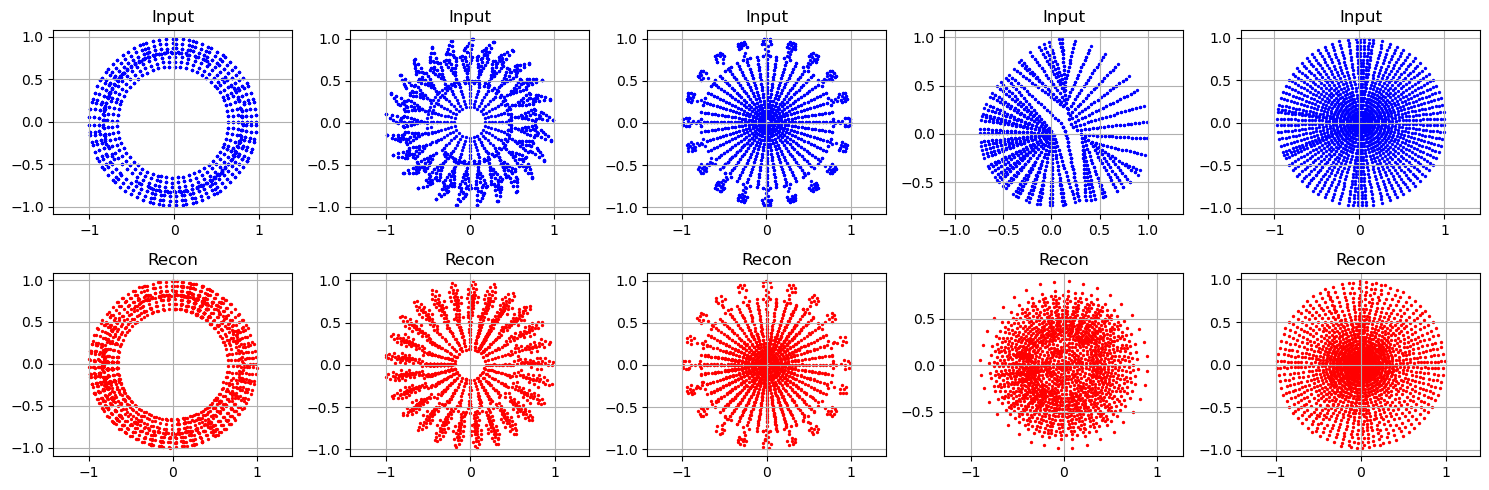

✅ Reconstruction plot saved to: F:\JupyterWork\Testing GAN\Coding of GAN\OutputAEgeneratedV1\recon_example.png


In [28]:
# =====================================================
# Inference: Conditional AutoEncoder (cAE) for G-code Layers
# Load trained model and visualize reconstructions
# =====================================================

import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import yaml
from box import Box

# =====================================================
# Dataset Class (same as training)
# =====================================================
class PointDataset(torch.utils.data.Dataset):
    def __init__(self, points_np, areas_np, label_int_np, num_classes):
        self.points = torch.tensor(points_np, dtype=torch.float32)              # (N,P,2)
        self.areas  = torch.tensor(areas_np, dtype=torch.float32)               # (N,1)
        self.labels = torch.tensor(label_int_np, dtype=torch.long)              # (N,)
        self.num_classes = num_classes

    def __len__(self):
        return self.points.shape[0]

    def __getitem__(self, idx):
        x   = self.points[idx]                         # (P,2)
        a   = self.areas[idx]                          # (1,)
        y   = self.labels[idx]                         # ()
        y1h = torch.nn.functional.one_hot(y, num_classes=self.num_classes).float()  # (C,)
        return x, a, y1h

# =====================================================
# Model Class (same as training)
# =====================================================
class PointCloudCAE(torch.nn.Module):
    def __init__(self, point_size, latent_size, cond_dim):
        super().__init__()
        self.P = point_size
        self.enc = torch.nn.Sequential(
            torch.nn.Linear(point_size * 2, 1024),
            torch.nn.ReLU(),
            torch.nn.Linear(1024, 512),
            torch.nn.ReLU(),
            torch.nn.Linear(512, 256),
            torch.nn.ReLU(),
            torch.nn.Linear(256, latent_size),
        )
        self.dec = torch.nn.Sequential(
            torch.nn.Linear(latent_size + cond_dim, 256),
            torch.nn.ReLU(),
            torch.nn.Linear(256, 512),
            torch.nn.ReLU(),
            torch.nn.Linear(512, 1024),
            torch.nn.ReLU(),
            torch.nn.Linear(1024, point_size * 2),
        )

    def forward(self, x, cond):
        B = x.shape[0]
        x_flat = x.view(B, -1)
        z = self.enc(x_flat)              # (B, latent)
        zc = torch.cat([z, cond], dim=1)  # (B, latent + cond)
        out_flat = self.dec(zc)           # (B, P*2)
        out = out_flat.view(B, self.P, 2)
        return out

# =====================================================
# Plotting Function
# =====================================================
def plotPCbatch_2d(batch_input, batch_output, show=True, save=False, name="plot"):
    batch_input = batch_input.cpu().numpy()
    batch_output = batch_output.cpu().numpy()
    cols = min(5, batch_input.shape[0])
    fig, axs = plt.subplots(2, cols, figsize=(3.0*cols, 5))
    if cols == 1:
        axs = np.array([[axs[0]], [axs[1]]])
    for i in range(cols):
        axs[0, i].scatter(batch_input[i, :, 0], batch_input[i, :, 1], c='b', s=2)
        axs[1, i].scatter(batch_output[i, :, 0], batch_output[i, :, 1], c='r', s=2)
        axs[0, i].axis('equal'); axs[1, i].axis('equal')
        axs[0, i].grid(True); axs[1, i].grid(True)
        axs[0, i].set_title("Input"); axs[1, i].set_title("Recon")
    plt.tight_layout()
    if save:
        plt.savefig(f"{name}.png")
        plt.close()
    elif show:
        plt.show()

# =====================================================
# Load config.yaml
# =====================================================
with open("config.yaml", "r") as file:
    args = Box(yaml.safe_load(file))

device = args.device if torch.cuda.is_available() else "cpu"

# =====================================================
# Load dataset
# =====================================================
data_file = Path.home() / args.data_dir / args.dataset
dataset_dict = np.load(data_file, allow_pickle=True).item()

raw_pc_array   = dataset_dict["data"]
areas_norm_all = dataset_dict["areas_norm"]
labels_file    = dataset_dict["labels"]
label_map      = dataset_dict["label_map"]

num_classes = len(label_map)

# Compute max points
max_points = max(
    pts[~np.all(pts==0, axis=1)].shape[0]
    for f in range(raw_pc_array.shape[0])
    for pts in raw_pc_array[f] if not np.all(pts==0)
)

# Normalize and repeat function
def normalize_and_repeat_2d(pc, target_size):
    centroid = np.mean(pc, axis=0)
    pc = pc - centroid
    max_dist = np.max(np.linalg.norm(pc, axis=1))
    pc = pc / max_dist if max_dist > 1e-8 else pc
    if pc.shape[0] < target_size:
        rep = (target_size // pc.shape[0]) + 1
        pc = np.tile(pc, (rep, 1))[:target_size]
    elif pc.shape[0] > target_size:
        pc = pc[:target_size]
    return pc

# Build dataset arrays
pts_list, area_list, label_list = [], [], []
for f in range(raw_pc_array.shape[0]):
    for l in range(raw_pc_array.shape[1]):
        pts = raw_pc_array[f, l]
        pts = pts[~np.all(pts==0, axis=1)]
        if pts.shape[0] > 0:
            pts_list.append(normalize_and_repeat_2d(pts, max_points))
            area_list.append(float(areas_norm_all[f, l]))
            label_list.append(int(labels_file[f]))

pc_array   = np.array(pts_list, dtype=np.float32)
area_array = np.array(area_list, dtype=np.float32).reshape(-1, 1)
label_int  = np.array(label_list, dtype=np.int64)

dataset = PointDataset(pc_array, area_array, label_int, num_classes)

# =====================================================
# Load trained model
# =====================================================
point_size = pc_array.shape[1]
cond_dim   = 1 + num_classes
cae = PointCloudCAE(point_size, args.latent_size, cond_dim).to(device)

model_path = Path(args.model_dir) / "cae_fold5.pt"
cae.load_state_dict(torch.load(model_path, map_location=device))
cae.eval()
print(f"✅ Loaded trained model from {model_path}")

# =====================================================
# Sample random dataset entries and run inference
# =====================================================
indices = np.random.choice(len(dataset), size=5, replace=False)
batch_in, cond_in = [], []
for idx in indices:
    x, a, y1h = dataset[idx]
    batch_in.append(x)
    cond_in.append(torch.cat([a, y1h], dim=0))
batch_in = torch.stack(batch_in).to(device)  # (B,P,2)
cond_in  = torch.stack(cond_in).to(device)   # (B,1+C)

# Run through model
with torch.no_grad():
    out = cae(batch_in, cond_in)


save_dir = Path(r"F:\JupyterWork\Testing GAN\Coding of GAN\OutputAEgeneratedV1")
save_dir.mkdir(parents=True, exist_ok=True)

save_path = save_dir / "recon_example.png"
# Plot & save
# Plot directly in Jupyter (blue = input, red = reconstruction)
plotPCbatch_2d(
    batch_in.cpu(), 
    out.cpu(), 
    save=False,   # don't save
    show=True     # show inline
)
print("✅ Reconstruction plot saved to:", save_path)


In [36]:
print("recon_output shape:", recon_output.shape)

recon_output shape: (5, 553, 2)


✅ Loaded trained model from F:\JupyterWork\Testing GAN\Coding of GAN\ModelAEV4\cae_fold5.pt


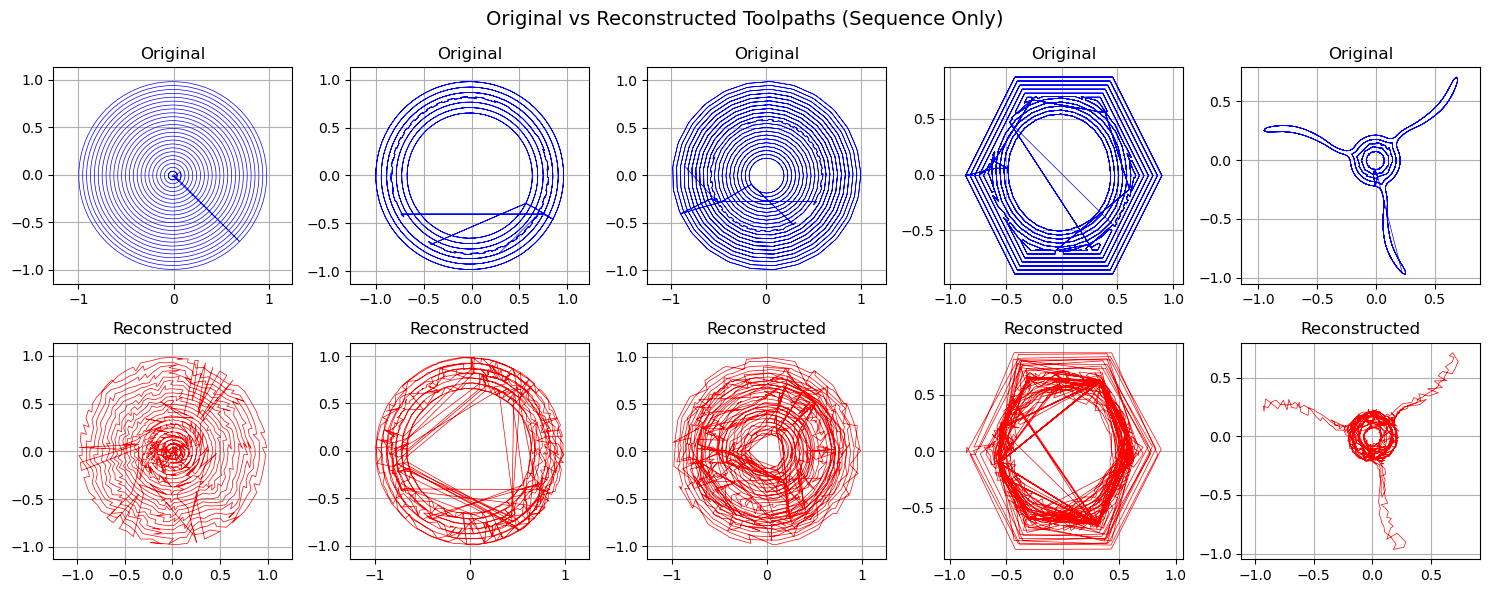

In [26]:
# =====================================================
# Inference + Toolpath Visualization (Sequence Only)
# =====================================================

import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import yaml
from box import Box

# =====================================================
# Dataset Class (same as training)
# =====================================================
class PointDataset(torch.utils.data.Dataset):
    def __init__(self, points_np, areas_np, label_int_np, num_classes):
        self.points = torch.tensor(points_np, dtype=torch.float32)              # (N,P,2)
        self.areas  = torch.tensor(areas_np, dtype=torch.float32)               # (N,1)
        self.labels = torch.tensor(label_int_np, dtype=torch.long)              # (N,)
        self.num_classes = num_classes

    def __len__(self):
        return self.points.shape[0]

    def __getitem__(self, idx):
        x   = self.points[idx]                         # (P,2)
        a   = self.areas[idx]                          # (1,)
        y   = self.labels[idx]                         # ()
        y1h = torch.nn.functional.one_hot(y, num_classes=self.num_classes).float()  # (C,)
        return x, a, y1h

# =====================================================
# Model Class (same as training)
# =====================================================
class PointCloudCAE(torch.nn.Module):
    def __init__(self, point_size, latent_size, cond_dim):
        super().__init__()
        self.P = point_size
        self.enc = torch.nn.Sequential(
            torch.nn.Linear(point_size * 2, 1024),
            torch.nn.ReLU(),
            torch.nn.Linear(1024, 512),
            torch.nn.ReLU(),
            torch.nn.Linear(512, 256),
            torch.nn.ReLU(),
            torch.nn.Linear(256, latent_size),
        )
        self.dec = torch.nn.Sequential(
            torch.nn.Linear(latent_size + cond_dim, 256),
            torch.nn.ReLU(),
            torch.nn.Linear(256, 512),
            torch.nn.ReLU(),
            torch.nn.Linear(512, 1024),
            torch.nn.ReLU(),
            torch.nn.Linear(1024, point_size * 2),
        )

    def forward(self, x, cond):
        B = x.shape[0]
        x_flat = x.view(B, -1)
        z = self.enc(x_flat)              # (B, latent)
        zc = torch.cat([z, cond], dim=1)  # (B, latent + cond)
        out_flat = self.dec(zc)           # (B, P*2)
        out = out_flat.view(B, self.P, 2)
        return out

# =====================================================
# Utility: Match reconstructed order to original sequence
# =====================================================
def connect_sequence(points, reference=None):
    if reference is None:
        return points
    ordered = []
    used = np.zeros(len(points), dtype=bool)
    for ref_pt in reference:
        dists = np.linalg.norm(points - ref_pt, axis=1)
        idx = np.argmin(dists + used * 1e6)
        ordered.append(points[idx])
        used[idx] = True
    return np.array(ordered)

# =====================================================
# Load config.yaml
# =====================================================
with open("config.yaml", "r") as file:
    args = Box(yaml.safe_load(file))

device = args.device if torch.cuda.is_available() else "cpu"

# =====================================================
# Load dataset
# =====================================================
data_file = Path.home() / args.data_dir / args.dataset
dataset_dict = np.load(data_file, allow_pickle=True).item()

raw_pc_array   = dataset_dict["data"]
areas_norm_all = dataset_dict["areas_norm"]
labels_file    = dataset_dict["labels"]
label_map      = dataset_dict["label_map"]

num_classes = len(label_map)

max_points = max(
    pts[~np.all(pts==0, axis=1)].shape[0]
    for f in range(raw_pc_array.shape[0])
    for pts in raw_pc_array[f] if not np.all(pts==0)
)

def normalize_and_repeat_2d(pc, target_size):
    centroid = np.mean(pc, axis=0)
    pc = pc - centroid
    max_dist = np.max(np.linalg.norm(pc, axis=1))
    pc = pc / max_dist if max_dist > 1e-8 else pc
    if pc.shape[0] < target_size:
        rep = (target_size // pc.shape[0]) + 1
        pc = np.tile(pc, (rep, 1))[:target_size]
    elif pc.shape[0] > target_size:
        pc = pc[:target_size]
    return pc

pts_list, area_list, label_list = [], [], []
for f in range(raw_pc_array.shape[0]):
    for l in range(raw_pc_array.shape[1]):
        pts = raw_pc_array[f, l]
        pts = pts[~np.all(pts==0, axis=1)]
        if pts.shape[0] > 0:
            pts_list.append(normalize_and_repeat_2d(pts, max_points))
            area_list.append(float(areas_norm_all[f, l]))
            label_list.append(int(labels_file[f]))

pc_array   = np.array(pts_list, dtype=np.float32)
area_array = np.array(area_list, dtype=np.float32).reshape(-1, 1)
label_int  = np.array(label_list, dtype=np.int64)

dataset = PointDataset(pc_array, area_array, label_int, num_classes)

# =====================================================
# Load trained model
# =====================================================
point_size = pc_array.shape[1]
cond_dim   = 1 + num_classes
cae = PointCloudCAE(point_size, args.latent_size, cond_dim).to(device)

model_path = Path(args.model_dir) / "cae_fold5.pt"
cae.load_state_dict(torch.load(model_path, map_location=device))
cae.eval()
print(f"✅ Loaded trained model from {model_path}")

# =====================================================
# Sample random dataset entries and run inference
# =====================================================
num_samples = 5
sample_indices = np.random.choice(len(dataset), size=num_samples, replace=False)
batch_in, cond_in = [], []
for idx in sample_indices:
    x, a, y1h = dataset[idx]
    batch_in.append(x)
    cond_in.append(torch.cat([a, y1h], dim=0))
batch_in = torch.stack(batch_in).to(device)
cond_in  = torch.stack(cond_in).to(device)

with torch.no_grad():
    out = cae(batch_in, cond_in)

recon_output = out.cpu().numpy()

# =====================================================
# Plot Original vs Reconstructed (Sequence Only)
# =====================================================
fig, axs = plt.subplots(2, num_samples, figsize=(3*num_samples, 6))
for i in range(num_samples):
    original = batch_in[i].cpu().numpy()
    reconstructed = recon_output[i]

    reconstructed = np.unique(reconstructed, axis=0)
    recon_seq = connect_sequence(reconstructed, reference=original)

    original_loop = np.vstack([original, original[0]])
    reconstructed_loop = np.vstack([recon_seq, recon_seq[0]])

    # Original
    axs[0, i].plot(original_loop[:, 0], original_loop[:, 1], '-', color='blue', linewidth=0.5)
    axs[0, i].set_title("Original")

    # Reconstructed (sequence only)
    axs[1, i].plot(reconstructed_loop[:, 0], reconstructed_loop[:, 1], '-', color='red', linewidth=0.5)
    axs[1, i].set_title("Reconstructed")

    axs[0, i].axis('equal')
    axs[1, i].axis('equal')
    axs[0, i].grid(True)                                           
    
    axs[1, i].grid(True)

plt.suptitle("Original vs Reconstructed Toolpaths (Sequence Only)", fontsize=14)
plt.tight_layout()
plt.show()


✅ Loaded trained model from F:\JupyterWork\Testing GAN\Coding of GAN\ModelAEV4\cae_fold5.pt


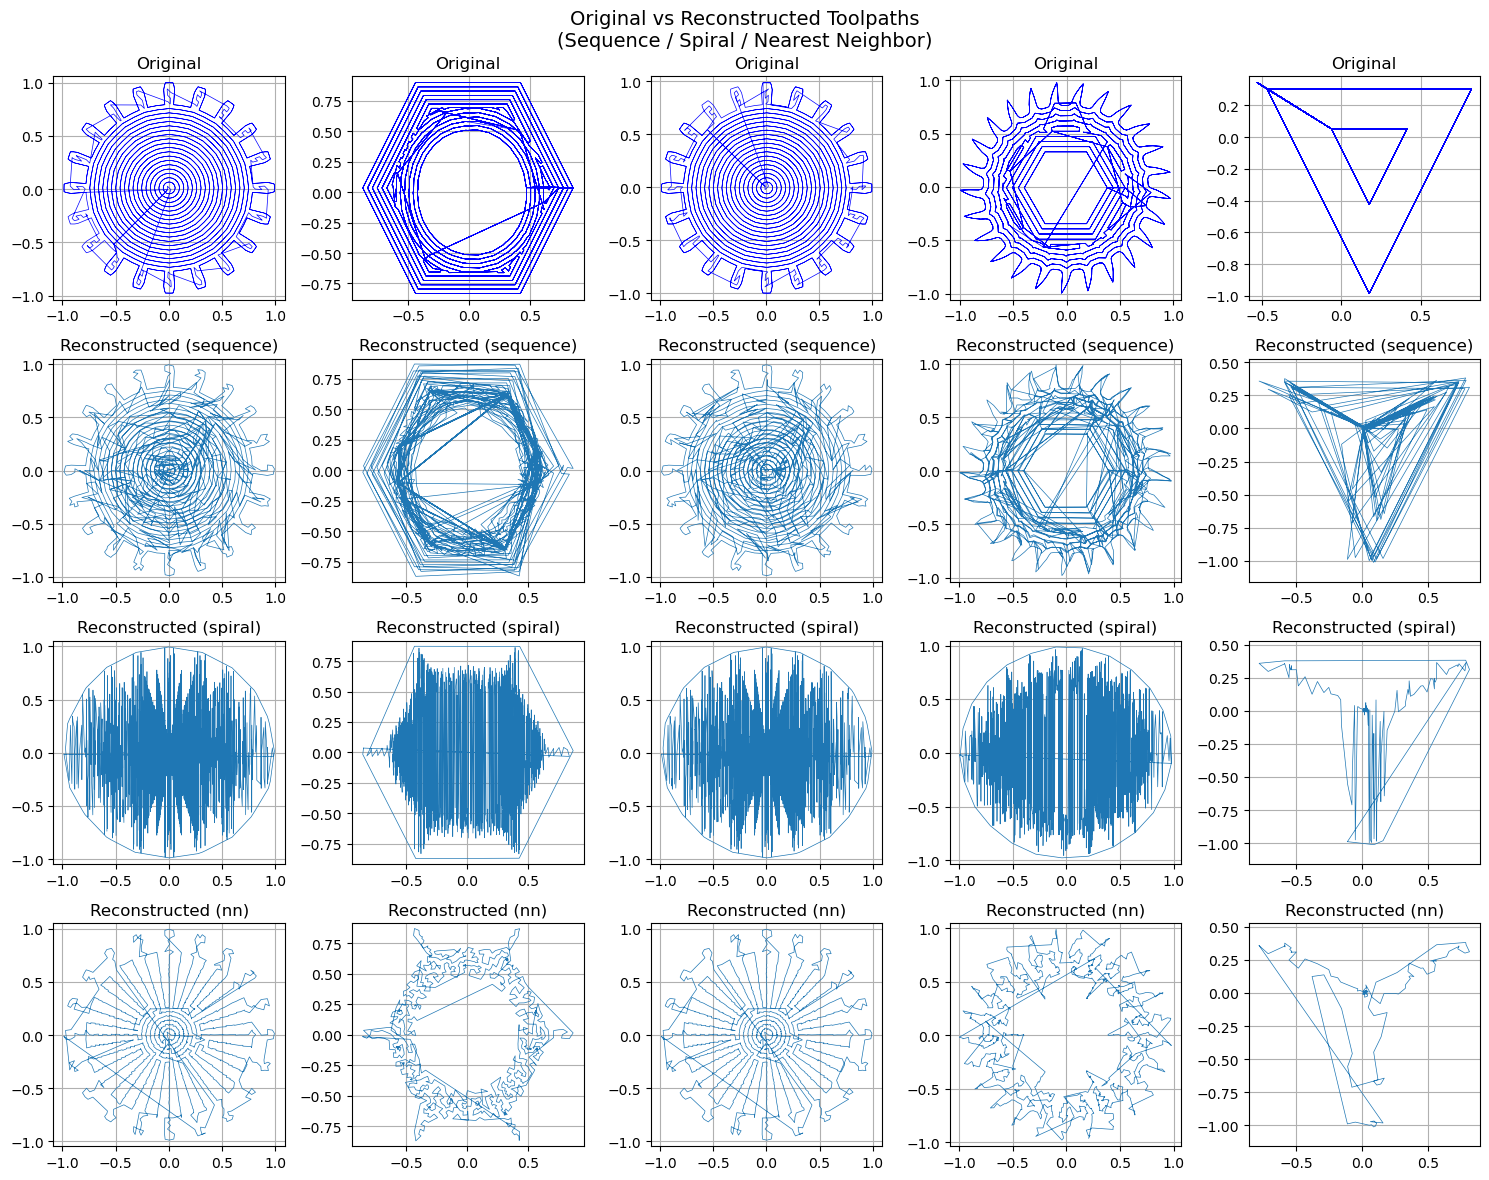

In [25]:
# =====================================================
# Inference + Toolpath Visualization 
# (Sequential / Spiral / Nearest Neighbor Modes)
# =====================================================

import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import yaml
from box import Box
from scipy.spatial import ConvexHull

# =====================================================
# Dataset Class (same as training)
# =====================================================
class PointDataset(torch.utils.data.Dataset):
    def __init__(self, points_np, areas_np, label_int_np, num_classes):
        self.points = torch.tensor(points_np, dtype=torch.float32)              # (N,P,2)
        self.areas  = torch.tensor(areas_np, dtype=torch.float32)               # (N,1)
        self.labels = torch.tensor(label_int_np, dtype=torch.long)              # (N,)
        self.num_classes = num_classes

    def __len__(self):
        return self.points.shape[0]

    def __getitem__(self, idx):
        x   = self.points[idx]                         # (P,2)
        a   = self.areas[idx]                          # (1,)
        y   = self.labels[idx]                         # ()
        y1h = torch.nn.functional.one_hot(y, num_classes=self.num_classes).float()  # (C,)
        return x, a, y1h

# =====================================================
# Model Class (same as training)
# =====================================================
class PointCloudCAE(torch.nn.Module):
    def __init__(self, point_size, latent_size, cond_dim):
        super().__init__()
        self.P = point_size
        self.enc = torch.nn.Sequential(
            torch.nn.Linear(point_size * 2, 1024),
            torch.nn.ReLU(),
            torch.nn.Linear(1024, 512),
            torch.nn.ReLU(),
            torch.nn.Linear(512, 256),
            torch.nn.ReLU(),
            torch.nn.Linear(256, latent_size),
        )
        self.dec = torch.nn.Sequential(
            torch.nn.Linear(latent_size + cond_dim, 256),
            torch.nn.ReLU(),
            torch.nn.Linear(256, 512),
            torch.nn.ReLU(),
            torch.nn.Linear(512, 1024),
            torch.nn.ReLU(),
            torch.nn.Linear(1024, point_size * 2),
        )

    def forward(self, x, cond):
        B = x.shape[0]
        x_flat = x.view(B, -1)
        z = self.enc(x_flat)              # (B, latent)
        zc = torch.cat([z, cond], dim=1)  # (B, latent + cond)
        out_flat = self.dec(zc)           # (B, P*2)
        out = out_flat.view(B, self.P, 2)
        return out

# =====================================================
# Utility Functions for Different Orderings
# =====================================================
def connect_sequence(points, reference=None):
    """Match reconstructed order to original sequence (reference-based)."""
    if reference is None:
        return points
    ordered = []
    used = np.zeros(len(points), dtype=bool)
    for ref_pt in reference:
        dists = np.linalg.norm(points - ref_pt, axis=1)
        idx = np.argmin(dists + used * 1e6)
        ordered.append(points[idx])
        used[idx] = True
    return np.array(ordered)

def order_points_spiral(points, min_gap=0.05):
    """Convex hull layering (spiral inward)."""
    if len(points) < 3:
        return points

    ordered = []
    pts = points.copy()
    centroid = np.mean(pts, axis=0)
    last_radius = 0.0

    while len(pts) >= 3:
        try:
            hull = ConvexHull(pts)
            hull_pts = pts[hull.vertices]

            # Compute radius
            hull_radius = np.mean(np.linalg.norm(hull_pts - centroid, axis=1))
            if hull_radius - last_radius < min_gap:
                break

            # Sort hull points by polar angle
            angles = np.arctan2(hull_pts[:, 1] - centroid[1], hull_pts[:, 0] - centroid[0])
            sort_idx = np.argsort(angles)
            hull_pts_sorted = hull_pts[sort_idx]

            ordered.extend(hull_pts_sorted.tolist())

            # Remove used hull points
            mask = np.ones(len(pts), dtype=bool)
            mask[hull.vertices] = False
            pts = pts[mask]

            last_radius = hull_radius
        except Exception:
            ordered.extend(pts.tolist())
            break

    # Add any remaining points
    if len(pts) > 0:
        ordered.extend(pts.tolist())

    return np.array(ordered)

def order_points_nn(points):
    """Nearest neighbor chaining through all points."""
    if len(points) == 0:
        return points
    pts = points.copy()
    ordered = []
    curr = pts[0]
    ordered.append(curr.tolist())
    pts = np.delete(pts, 0, axis=0)

    while len(pts) > 0:
        dists = np.linalg.norm(pts - curr, axis=1)
        idx = np.argmin(dists)
        curr = pts[idx]
        ordered.append(curr.tolist())
        pts = np.delete(pts, idx, axis=0)

    return np.array(ordered)

# =====================================================
# Load config.yaml
# =====================================================
with open("config.yaml", "r") as file:
    args = Box(yaml.safe_load(file))

device = args.device if torch.cuda.is_available() else "cpu"

# =====================================================
# Load dataset
# =====================================================
data_file = Path.home() / args.data_dir / args.dataset
dataset_dict = np.load(data_file, allow_pickle=True).item()

raw_pc_array   = dataset_dict["data"]
areas_norm_all = dataset_dict["areas_norm"]
labels_file    = dataset_dict["labels"]
label_map      = dataset_dict["label_map"]

num_classes = len(label_map)

max_points = max(
    pts[~np.all(pts==0, axis=1)].shape[0]
    for f in range(raw_pc_array.shape[0])
    for pts in raw_pc_array[f] if not np.all(pts==0)
)

def normalize_and_repeat_2d(pc, target_size):
    centroid = np.mean(pc, axis=0)
    pc = pc - centroid
    max_dist = np.max(np.linalg.norm(pc, axis=1))
    pc = pc / max_dist if max_dist > 1e-8 else pc
    if pc.shape[0] < target_size:
        rep = (target_size // pc.shape[0]) + 1
        pc = np.tile(pc, (rep, 1))[:target_size]
    elif pc.shape[0] > target_size:
        pc = pc[:target_size]
    return pc

pts_list, area_list, label_list = [], [], []
for f in range(raw_pc_array.shape[0]):
    for l in range(raw_pc_array.shape[1]):
        pts = raw_pc_array[f, l]
        pts = pts[~np.all(pts==0, axis=1)]
        if pts.shape[0] > 0:
            pts_list.append(normalize_and_repeat_2d(pts, max_points))
            area_list.append(float(areas_norm_all[f, l]))
            label_list.append(int(labels_file[f]))

pc_array   = np.array(pts_list, dtype=np.float32)
area_array = np.array(area_list, dtype=np.float32).reshape(-1, 1)
label_int  = np.array(label_list, dtype=np.int64)

dataset = PointDataset(pc_array, area_array, label_int, num_classes)

# =====================================================
# Load trained model
# =====================================================
point_size = pc_array.shape[1]
cond_dim   = 1 + num_classes
cae = PointCloudCAE(point_size, args.latent_size, cond_dim).to(device)

model_path = Path(args.model_dir) / "cae_fold5.pt"
cae.load_state_dict(torch.load(model_path, map_location=device))
cae.eval()
print(f"✅ Loaded trained model from {model_path}")

# =====================================================
# Sample random dataset entries and run inference
# =====================================================
num_samples = 5
sample_indices = np.random.choice(len(dataset), size=num_samples, replace=False)
batch_in, cond_in = [], []
for idx in sample_indices:
    x, a, y1h = dataset[idx]
    batch_in.append(x)
    cond_in.append(torch.cat([a, y1h], dim=0))
batch_in = torch.stack(batch_in).to(device)
cond_in  = torch.stack(cond_in).to(device)

with torch.no_grad():
    out = cae(batch_in, cond_in)

recon_output = out.cpu().numpy()

# =====================================================
# Plot with Multiple Ordering Modes
# =====================================================
modes = ["sequence", "spiral", "nn"]  # choose any subset
fig, axs = plt.subplots(len(modes)+1, num_samples, figsize=(3*num_samples, 3*(len(modes)+1)))

for i in range(num_samples):
    original = batch_in[i].cpu().numpy()
    reconstructed = recon_output[i]

    reconstructed = np.unique(reconstructed, axis=0)

    # === Original ===
    orig_loop = np.vstack([original, original[0]])
    axs[0, i].plot(orig_loop[:, 0], orig_loop[:, 1], '-', color='blue', linewidth=0.5)
    axs[0, i].set_title("Original")
    axs[0, i].axis('equal'); axs[0, i].grid(True)

    # === Reconstructed with each mode ===
    for j, mode in enumerate(modes):
        if mode == "sequence":
            recon_seq = connect_sequence(reconstructed, reference=original)
        elif mode == "spiral":
            recon_seq = order_points_spiral(reconstructed)
        elif mode == "nn":
            recon_seq = order_points_nn(reconstructed)
        else:
            continue

        recon_loop = np.vstack([recon_seq, recon_seq[0]])
        axs[j+1, i].plot(recon_loop[:, 0], recon_loop[:, 1], '-', linewidth=0.5)
        axs[j+1, i].set_title(f"Reconstructed ({mode})")
        axs[j+1, i].axis('equal'); axs[j+1, i].grid(True)

plt.suptitle("Original vs Reconstructed Toolpaths\n(Sequence / Spiral / Nearest Neighbor)", fontsize=14)
plt.tight_layout()
plt.show()
